<a href="https://colab.research.google.com/github/Chathuwa99/Agri_Bloom/blob/Yehan/Agri_Bloom_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Agri_Bloom — Model Training Pipeline
**CM3603 Edge AI · Tomato Seedling Health Classifier**

This notebook trains a 7-class MLP that runs on the ESP32 via TFLite Micro.

### Pipeline
1. Mount Google Drive & load dataset
2. Explore & validate data
3. Preprocess (scale + encode)
4. Train Keras MLP
5. Evaluate (F1, confusion matrix)
6. Convert to TFLite INT8
7. Generate `model.h` for ESP32

> **Runtime**: Runtime → Change runtime type → T4 GPU

---
## Cell 1 — Install & Import Libraries & Packages

In [ ]:
# Install
!pip install -q tensorflow scikit-learn pandas numpy matplotlib seaborn

import os, shutil, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {tf.config.list_physical_devices("GPU")}')

TensorFlow version : 2.19.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Cell 2 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

CSV_PATH = '/content/drive/MyDrive/PlantGuard/tomato_seedling_dataset.csv'

# Output folder (saved back to Drive)
OUTPUT_DIR = '/content/drive/MyDrive/PlantGuard/model_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'CSV path   : {CSV_PATH}')
print(f'Output dir : {OUTPUT_DIR}')
print(f'CSV exists : {os.path.exists(CSV_PATH)}')

Mounted at /content/drive
CSV path   : /content/drive/MyDrive/PlantGuard/tomato_seedling_dataset.csv
Output dir : /content/drive/MyDrive/PlantGuard/model_output
CSV exists : True


---
## Cell 3 — Load & Explore Dataset

In [ ]:
df = pd.read_csv(CSV_PATH)

# Auto-detect column names
# Expected: moisture, lux (or light), temperature, humidity, pH, label
print('Columns found:', df.columns.tolist())
print(f'Shape        : {df.shape}')
print(f'Null values  :\n{df.isnull().sum()}')
print(f'\nFirst 5 rows:')
df.head()

Columns found: ['moisture_pct', 'lux', 'temperature', 'humidity_pct', 'pH', 'label', 'label_name']
Shape        : (3800, 7)
Null values  :
moisture_pct    0
lux             0
temperature     0
humidity_pct    0
pH              0
label           0
label_name      0
dtype: int64

First 5 rows:


,moisture_pct,lux,temperature,humidity_pct,pH,label,label_name
0,13.6,3851,18.8,33.2,6.74,1,Water_Stress
1,68.9,4401,18.0,64.6,6.24,0,Healthy
2,66.4,4501,19.2,79.3,6.71,0,Healthy
3,41.1,3740,24.3,56.8,5.34,5,Nutrient_Deficiency
4,56.6,3451,21.2,60.6,5.09,5,Nutrient_Deficiency


Feature columns : ['moisture_pct', 'lux', 'temperature', 'humidity_pct', 'pH']
Label column    : label

Class counts:
  Class 0 (Healthy             ) : 700 samples
  Class 1 (Water Stress        ) : 600 samples
  Class 2 (Root Rot Risk       ) : 500 samples
  Class 3 (Heat Stress         ) : 500 samples
  Class 4 (Fungal Risk         ) : 500 samples
  Class 5 (Nutrient Deficiency ) : 500 samples
  Class 6 (Light Deficiency    ) : 500 samples


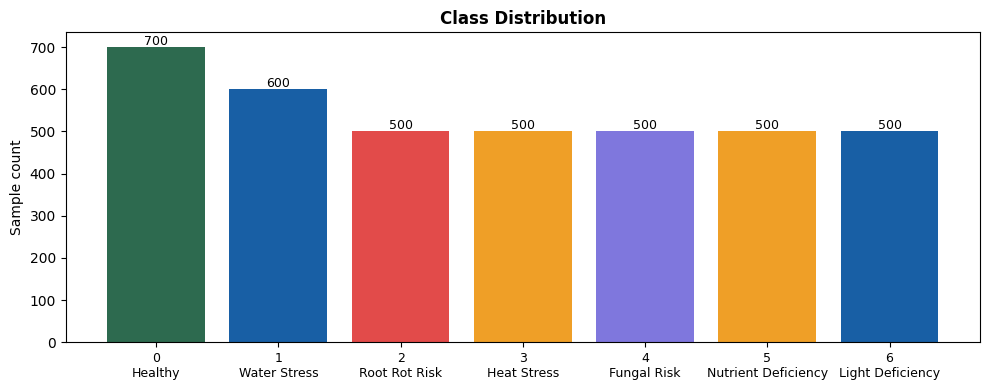

In [ ]:
#  Class distribution
CLASS_NAMES = [
    'Healthy',
    'Water Stress',
    'Root Rot Risk',
    'Heat Stress',
    'Fungal Risk',
    'Nutrient Deficiency',
    'Light Deficiency'
]

# Identify the label column (last column or column named 'label'/'class')
LABEL_COL = 'label'
FEATURE_COLS = [c for c in df.columns if c != LABEL_COL and c != 'label_name']

print(f'Feature columns : {FEATURE_COLS}')
print(f'Label column    : {LABEL_COL}')
print(f'\nClass counts:')
counts = df[LABEL_COL].value_counts().sort_index()
for idx, cnt in counts.items():
    name = CLASS_NAMES[int(idx)] if int(idx) < len(CLASS_NAMES) else str(idx)
    print(f'  Class {idx} ({name:<20}) : {cnt} samples')

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(counts)), counts.values,
              color=['#2d6a4f','#185FA5','#E24B4A','#EF9F27','#7F77DD','#EF9F27','#185FA5'])
ax.set_xticks(range(len(counts)))
ax.set_xticklabels([f'{i}\n{CLASS_NAMES[i]}' for i in range(len(counts))], fontsize=9)
ax.set_title('Class Distribution', fontweight='bold')
ax.set_ylabel('Sample count')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Feature statistics per class
print('Feature statistics per class:')
df.groupby(LABEL_COL)[FEATURE_COLS].mean().round(2)

Feature statistics per class:


,moisture_pct,lux,temperature,humidity_pct,pH
label,,,,,
0,64.96,4009.04,22.44,69.80,6.39
1,21.65,3716.98,26.72,39.96,6.29
2,92.35,1264.05,22.14,87.50,6.26
3,42.98,4589.70,37.10,29.88,6.30
4,70.01,874.39,21.48,92.54,6.31
5,54.90,2773.36,22.37,62.09,4.92
6,59.87,559.24,20.01,65.10,6.31


---
## Cell 4 — Preprocess

In [ ]:
# Features & labels
X = df[FEATURE_COLS].values.astype(np.float32)
y = df[LABEL_COL].values.astype(int)

NUM_CLASSES  = len(np.unique(y))   #7 classes
NUM_FEATURES = X.shape[1]          #5 features
print(f'Features  : {NUM_FEATURES}')
print(f'Classes   : {NUM_CLASSES}')
print(f'Samples   : {len(X)}')

# Train / Test split (80 / 20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'\nTrain samples : {len(X_train)}')
print(f'Test  samples : {len(X_test)}')

# Normalize features (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save scaler params for Welford init on ESP32
scaler_params = {
    'mean_': scaler.mean_.tolist(),
    'scale_': scaler.scale_.tolist(),
    'feature_names': FEATURE_COLS
}
import json
scaler_path = os.path.join(OUTPUT_DIR, 'scaler_params.json')
with open(scaler_path, 'w') as f:
    json.dump(scaler_params, f, indent=2)
print(f'\nScaler params saved → {scaler_path}')
print('Means  :', scaler.mean_.round(3))
print('Scales :', scaler.scale_.round(3))

#  One-hot encode labels
y_train_ohe = keras.utils.to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_ohe  = keras.utils.to_categorical(y_test,  num_classes=NUM_CLASSES)
print(f'\ny_train shape : {y_train_ohe.shape}')
print(f'y_test  shape : {y_test_ohe.shape}')

Features  : 5
Classes   : 7
Samples   : 3800

Train samples : 3040
Test  samples : 760

Scaler params saved → /content/drive/MyDrive/PlantGuard/model_output/scaler_params.json
Means  : [  57.429 2645.542   24.578   63.531    6.13 ]
Scales : [2.146000e+01 1.718106e+03 6.101000e+00 2.165800e+01 5.610000e-01]

y_train shape : (3040, 7)
y_test  shape : (760, 7)


---
## Cell 5 — Build Model

In [ ]:
#  MLP Architecture (kept small for TFLite Micro ~12 KB target)
def build_model(num_features, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(num_features,)),
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(num_classes, activation='softmax')
    ], name='PlantGuard_MLP')
    return model

model = build_model(NUM_FEATURES, NUM_CLASSES)
model.summary()

# Count parameters
total_params = model.count_params()
print(f'\nTotal parameters : {total_params:,}')
print(f'Estimated size   : ~{total_params * 4 / 1024:.1f} KB (float32)')
print(f'After INT8 quant : ~{total_params * 1 / 1024:.1f} KB (estimate)')

Model: "PlantGuard_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 967 (3.78 KB)

 Trainable params: 903 (3.53 KB)

 Non-trainable params: 64 (256.00 B)


Total parameters : 967
Estimated size   : ~3.8 KB (float32)
After INT8 quant : ~0.9 KB (estimate)


---
## Cell 6 — Train

In [ ]:
#  Compute class weights (handles mild imbalance: 700 vs 500)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_arr))
print('Class weights:', {k: round(v, 3) for k, v in class_weight_dict.items()})

#  Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#  Callbacks
KERAS_MODEL_PATH = os.path.join(OUTPUT_DIR, 'plantguard_model.keras')

cb_list = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=20,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=8, min_lr=1e-5, verbose=1
    ),
    callbacks.ModelCheckpoint(
        KERAS_MODEL_PATH, monitor='val_accuracy',
        save_best_only=True, verbose=0
    )
]

#  Train
EPOCHS     = 150
BATCH_SIZE = 64

history = model.fit(
    X_train_scaled, y_train_ohe,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    class_weight=class_weight_dict,
    callbacks=cb_list,
    verbose=1
)

print(f'\nBest model saved → {KERAS_MODEL_PATH}')

Class weights: {0: np.float64(0.776), 1: np.float64(0.905), 2: np.float64(1.086), 3: np.float64(1.086), 4: np.float64(1.086), 5: np.float64(1.086), 6: np.float64(1.086)}
Epoch 1/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.3587 - loss: 1.6541 - val_accuracy: 0.6360 - val_loss: 1.5685 - learning_rate: 0.0010
Epoch 2/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7036 - loss: 0.9794 - val_accuracy: 0.9452 - val_loss: 1.1457 - learning_rate: 0.0010
Epoch 3/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8526 - loss: 0.6126 - val_accuracy: 0.9803 - val_loss: 0.7722 - learning_rate: 0.0010
Epoch 4/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9156 - loss: 0.4008 - val_accuracy: 0.9846 - val_loss: 0.4895 - learning_rate: 0.0010
Epoch 5/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9385 - loss: 0.2881 - val_accuracy: 0.9868 - val_loss: 0.3111 - learning_rate: 0.0010
Epoch 6/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9578 - lo

---
## Cell 7 — Training Curves

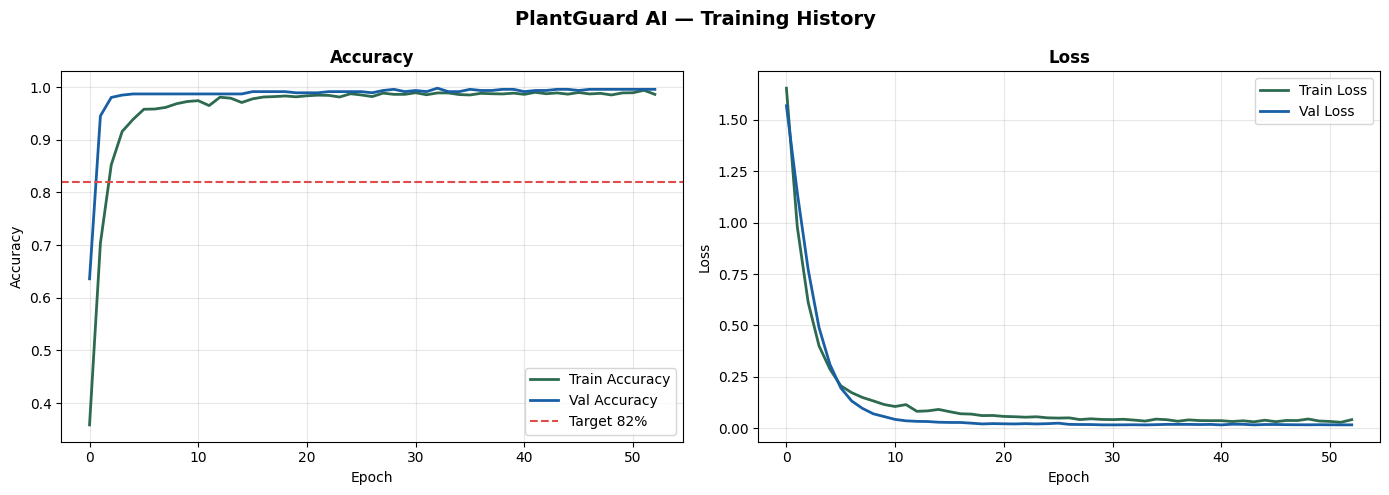

Saved → /content/drive/MyDrive/PlantGuard/model_output/training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='#2d6a4f', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#185FA5', linewidth=2)
axes[0].axhline(0.82, color='#E24B4A', linestyle='--', linewidth=1.5, label='Target 82%')
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='#2d6a4f', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#185FA5', linewidth=2)
axes[1].set_title('Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('PlantGuard AI — Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'training_curves.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {plot_path}')

---
## Cell 8 — Evaluate on Test Set

In [ ]:
# Predictions
y_pred_proba = model.predict(X_test_scaled, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

# Overall metrics
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_ohe, verbose=0)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print('═' * 55)
print(f'  Test Accuracy  : {test_acc * 100:.2f}%')
print(f'  Macro F1 Score : {macro_f1:.4f}  (target ≥ 0.82)')
status = 'TARGET MET' if macro_f1 >= 0.82 else 'BELOW TARGET — see tuning tips below'
print(f'  Status         : {status}')
print('═' * 55)

#  Per-class report
print('\nPer-class Classification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=CLASS_NAMES,
    digits=3
))

═══════════════════════════════════════════════════════
  Test Accuracy  : 99.47%
  Macro F1 Score : 0.9946  (target ≥ 0.82)
  Status         : TARGET MET
═══════════════════════════════════════════════════════

Per-class Classification Report:
                     precision    recall  f1-score   support

            Healthy      1.000     1.000     1.000       140
       Water Stress      0.983     0.992     0.988       120
      Root Rot Risk      1.000     0.990     0.995       100
        Heat Stress      0.990     0.980     0.985       100
        Fungal Risk      0.990     1.000     0.995       100
Nutrient Deficiency      1.000     1.000     1.000       100
   Light Deficiency      1.000     1.000     1.000       100

           accuracy                          0.995       760
          macro avg      0.995     0.995     0.995       760
       weighted avg      0.995     0.995     0.995       760



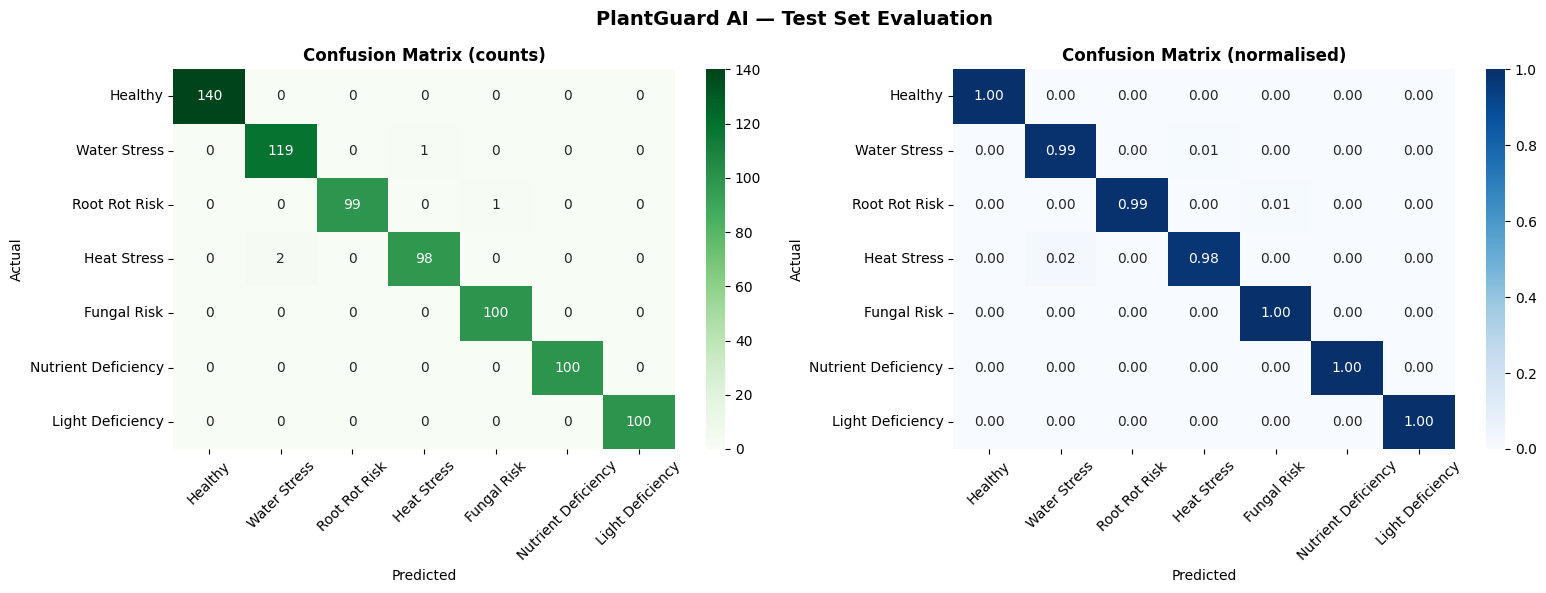

Saved → /content/drive/MyDrive/PlantGuard/model_output/confusion_matrix.png


In [ ]:
#  Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

# Normalised
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (normalised)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('PlantGuard AI — Test Set Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {cm_path}')

---
## Cell 9 — Convert to TFLite INT8


In [ ]:
# Representative dataset for INT8 calibration
# TFLite needs ~100–256 representative samples to calibrate quantization ranges.
# We use a random sample from the training set.

NUM_CALIB_SAMPLES = 256
calib_indices = np.random.choice(len(X_train_scaled), NUM_CALIB_SAMPLES, replace=False)
calib_data = X_train_scaled[calib_indices].astype(np.float32)

def representative_dataset():
    for i in range(NUM_CALIB_SAMPLES):
        sample = calib_data[i:i+1]       # shape (1, 5)
        yield [sample]

# Convert
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations              = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset     = representative_dataset
converter.target_spec.supported_ops  = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type       = tf.int8
converter.inference_output_type      = tf.int8

tflite_model = converter.convert()

#  Save .tflite file
TFLITE_PATH = os.path.join(OUTPUT_DIR, 'plantguard_model.tflite')
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024
print(f'TFLite model saved → {TFLITE_PATH}')
print(f'File size          : {size_kb:.2f} KB  (target ≤ 12 KB)')

if size_kb <= 12:
    print(' Size OK for ESP32')
else:
    print('  Too large — consider reducing Dense(32) to Dense(24)')

Saved artifact at '/tmp/tmp3votnux9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  138442785537296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138442785536912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138442647865680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138442647866064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138442647864912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138442647865296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138442785537872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138442647866448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138442647863376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138442647865104: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


TFLite model saved → /content/drive/MyDrive/PlantGuard/model_output/plantguard_model.tflite
File size          : 4.81 KB  (target ≤ 12 KB)
 Size OK for ESP32


In [ ]:
# Verify INT8 model accuracy (should be within ~1–2% of float model)
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print('Input  dtype  :', input_details[0]['dtype'])
print('Input  scale  :', input_details[0]['quantization'])
print('Output dtype  :', output_details[0]['dtype'])
print('Output scale  :', output_details[0]['quantization'])

# Run inference on test set
input_scale, input_zero_point   = input_details[0]['quantization']
output_scale, output_zero_point = output_details[0]['quantization']

tflite_preds = []
for sample in X_test_scaled:
    # Quantize input to int8
    inp = (sample / input_scale + input_zero_point).astype(np.int8).reshape(1, -1)
    interpreter.set_tensor(input_details[0]['index'], inp)
    interpreter.invoke()
    out = interpreter.get_tensor(output_details[0]['index'])[0]  # int8
    tflite_preds.append(np.argmax(out))

tflite_preds = np.array(tflite_preds)
tflite_acc = np.mean(tflite_preds == y_test)
tflite_f1  = f1_score(y_test, tflite_preds, average='macro')

print(f'\nINT8 TFLite Accuracy : {tflite_acc * 100:.2f}%')
print(f'INT8 TFLite Macro F1 : {tflite_f1:.4f}')
print(f'Float vs INT8 drop   : {(test_acc - tflite_acc) * 100:.2f}%  (acceptable ≤ 2%)')

Input  dtype  : <class 'numpy.int8'>
Input  scale  : (0.02252727560698986, 2)
Output dtype  : <class 'numpy.int8'>
Output scale  : (0.00390625, -128)

INT8 TFLite Accuracy : 99.47%
INT8 TFLite Macro F1 : 0.9946
Float vs INT8 drop   : 0.00%  (acceptable ≤ 2%)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


---
## Cell 10 — Create `model.h` for ESP32

In [ ]:
# Convert .tflite binary → C byte array
# This is what goes inside the ESP32 PlatformIO project.

MODEL_H_PATH = os.path.join(OUTPUT_DIR, 'model.h')

with open(TFLITE_PATH, 'rb') as f:
    model_bytes = f.read()

def to_c_array(data, var_name='plantguard_model_data'):
    hex_bytes = ', '.join(f'0x{b:02x}' for b in data)
    lines = []
    lines.append('#pragma once')
    lines.append('// PlantGuard AI — TFLite Micro model')
    lines.append(f'// Generated from plantguard_model.tflite ({len(data)} bytes)')
    lines.append(f'// Classes: Healthy | Water Stress | Root Rot Risk | Heat Stress')
    lines.append(f'//          Fungal Risk | Nutrient Deficiency | Light Deficiency')
    lines.append('')
    lines.append(f'const unsigned int {var_name}_len = {len(data)};')
    lines.append('')
    lines.append(f'alignas(8) const unsigned char {var_name}[] = {{')

    # 12 bytes per line for readability
    chunk = 12
    byte_list = [f'0x{b:02x}' for b in data]
    for i in range(0, len(byte_list), chunk):
        row = ', '.join(byte_list[i:i+chunk])
        lines.append(f'  {row},')

    lines.append('};')
    return '\n'.join(lines)

header_content = to_c_array(model_bytes)

with open(MODEL_H_PATH, 'w') as f:
    f.write(header_content)

print(f'model.h saved → {MODEL_H_PATH}')
print(f'File size     : {len(model_bytes)} bytes ({len(model_bytes)/1024:.2f} KB)')
print()
# Preview first few lines
preview_lines = header_content.split('\n')[:12]
print('\n'.join(preview_lines))
print('  ...')

model.h saved → /content/drive/MyDrive/PlantGuard/model_output/model.h
File size     : 4928 bytes (4.81 KB)

#pragma once
// PlantGuard AI — TFLite Micro model
// Generated from plantguard_model.tflite (4928 bytes)
// Classes: Healthy | Water Stress | Root Rot Risk | Heat Stress
//          Fungal Risk | Nutrient Deficiency | Light Deficiency

const unsigned int plantguard_model_data_len = 4928;

alignas(8) const unsigned char plantguard_model_data[] = {
  0x20, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x00, 0x00, 0x00, 0x00,
  0x14, 0x00, 0x20, 0x00, 0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00,
  0x0c, 0x00, 0x00, 0x00, 0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00,
  ...


---
## Cell 11 — Save Scaler as C Header (for ESP32 Welford init)

In [ ]:
# scaler_params.h — initial means/stds for Welford OnlineLearner
SCALER_H_PATH = os.path.join(OUTPUT_DIR, 'scaler_params.h')

means  = scaler.mean_
scales = scaler.scale_

lines = [
    '#pragma once',
    '// PlantGuard AI — StandardScaler parameters',
    '// Used to initialise the Welford OnlineLearner on the ESP32.',
    '// Feature order: ' + ', '.join(FEATURE_COLS),
    '',
    f'const int    SCALER_N_FEATURES = {NUM_FEATURES};',
    '',
    '// Training-set feature means',
    'const float SCALER_MEAN[' + str(NUM_FEATURES) + '] = {',
]
for i, (name, val) in enumerate(zip(FEATURE_COLS, means)):
    comma = ',' if i < NUM_FEATURES - 1 else ''
    lines.append(f'  {val:.6f}{comma}  // {name}')
lines.append('};')
lines.append('')
lines.append('// Training-set feature standard deviations')
lines.append('const float SCALER_STD[' + str(NUM_FEATURES) + '] = {')
for i, (name, val) in enumerate(zip(FEATURE_COLS, scales)):
    comma = ',' if i < NUM_FEATURES - 1 else ''
    lines.append(f'  {val:.6f}{comma}  // {name}')
lines.append('};')

content = '\n'.join(lines)
with open(SCALER_H_PATH, 'w') as f:
    f.write(content)

print(f'scaler_params.h saved → {SCALER_H_PATH}')
print()
print(content)

scaler_params.h saved → /content/drive/MyDrive/PlantGuard/model_output/scaler_params.h

#pragma once
// PlantGuard AI — StandardScaler parameters
// Used to initialise the Welford OnlineLearner on the ESP32.
// Feature order: moisture_pct, lux, temperature, humidity_pct, pH

const int    SCALER_N_FEATURES = 5;

// Training-set feature means
const float SCALER_MEAN[5] = {
  57.428980,  // moisture_pct
  2645.541776,  // lux
  24.577763,  // temperature
  63.531447,  // humidity_pct
  6.130487  // pH
};

// Training-set feature standard deviations
const float SCALER_STD[5] = {
  21.459878,  // moisture_pct
  1718.105827,  // lux
  6.101036,  // temperature
  21.657927,  // humidity_pct
  0.561500  // pH
};
